<a href="https://colab.research.google.com/github/athfizh/PemMes26_05_Hafizh/blob/main/JS06/JS06-TugasLab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---


# **Klasifikasi 2 - Tugas Lab 1**


---

---


# **Persiapan - Mount Google Drive**


---

In [1]:
from google.colab import drive
drive.mount('/content/drive')

# folder data praktikum di Google Drive
base_path = '/content/drive/MyDrive/COLLEGE/SEM 5/PEMMES/DATA/images-week06'
print('Lokasi data:', base_path)

Mounted at /content/drive
Lokasi data: /content/drive/MyDrive/COLLEGE/SEM 5/PEMMES/DATA/images-week06


> Data dibaca dari folder `images-week06` di Google Drive, jadi Drive di-mount terlebih dahulu dan lokasinya disimpan pada variabel `base_path`.

---


# **Langkah 1 - Load Data**


---

In [2]:
# Load data
import pandas as pd
data = pd.read_csv(base_path + '/voice.csv')
data.head()

,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,...,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx,label
0,0.059781,0.064241,0.032027,0.015071,0.090193,0.075122,12.863462,274.402906,0.893369,0.491918,...,0.059781,0.084279,0.015702,0.275862,0.007812,0.007812,0.007812,0.000000,0.000000,male
1,0.066009,0.067310,0.040229,0.019414,0.092666,0.073252,22.423285,634.613855,0.892193,0.513724,...,0.066009,0.107937,0.015826,0.250000,0.009014,0.007812,0.054688,0.046875,0.052632,male
2,0.077316,0.083829,0.036718,0.008701,0.131908,0.123207,30.757155,1024.927705,0.846389,0.478905,...,0.077316,0.098706,0.015656,0.271186,0.007990,0.007812,0.015625,0.007812,0.046512,male
3,0.151228,0.072111,0.158011,0.096582,0.207955,0.111374,1.232831,4.177296,0.963322,0.727232,...,0.151228,0.088965,0.017798,0.250000,0.201497,0.007812,0.562500,0.554688,0.247119,male
4,0.135120,0.079146,0.124656,0.078720,0.206045,0.127325,1.101174,4.333713,0.971955,0.783568,...,0.135120,0.106398,0.016931,0.266667,0.712812,0.007812,5.484375,5.476562,0.208274,male


---


# **Langkah 2 - Eksplorasi Data**


---

In [3]:
print('Ukuran data:', data.shape)
print('Jumlah nilai kosong:', data.isnull().sum().sum())
print()
print(data['label'].value_counts())
data.describe().T.head(10)

Ukuran data: (3168, 21)
Jumlah nilai kosong: 0

label
male      1584
female    1584
Name: count, dtype: int64


,count,mean,std,min,25%,50%,75%,max
meanfreq,3168.0,0.180907,0.029918,0.039363,0.163662,0.184838,0.199146,0.251124
sd,3168.0,0.057126,0.016652,0.018363,0.041954,0.059155,0.067020,0.115273
median,3168.0,0.185621,0.036360,0.010975,0.169593,0.190032,0.210618,0.261224
Q25,3168.0,0.140456,0.048680,0.000229,0.111087,0.140286,0.175939,0.247347
Q75,3168.0,0.224765,0.023639,0.042946,0.208747,0.225684,0.243660,0.273469
IQR,3168.0,0.084309,0.042783,0.014558,0.042560,0.094280,0.114175,0.252225
skew,3168.0,3.140168,4.240529,0.141735,1.649569,2.197101,2.931694,34.725453
kurt,3168.0,36.568461,134.928661,2.068455,5.669547,8.318463,13.648905,1309.612887
sp.ent,3168.0,0.895127,0.044980,0.738651,0.861811,0.901767,0.928713,0.981997
sfm,3168.0,0.408216,0.177521,0.036876,0.258041,0.396335,0.533676,0.842936


> Data `voice.csv` terdiri dari 3.168 baris dengan 20 fitur akustik dan 1 kolom label (male/female). Tidak ada nilai kosong dan jumlah kedua kelas seimbang (1.584 male dan 1.584 female), sehingga akurasi cukup layak dipakai sebagai metrik. Rentang nilai antarfitur juga berbeda jauh (contohnya `kurt` bisa mencapai ratusan sampai ribuan, sedangkan `meanfreq` di bawah 1), maka dilakukan standardisasi sebelum melatih SVM.

---


# **Langkah 3 - Preprocessing**


---

In [4]:
X = data.iloc[:, :-1]   # semua kolom kecuali label
y = data.iloc[:, -1]    # kolom label terakhir (male / female)
print('Fitur:', X.shape, '| Label:', y.shape)

Fitur: (3168, 20) | Label: (3168,)


---


# **Langkah 4 - Bangun Model SVM (Split x Kernel)**


---

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

rasio_split = {'70:30': 0.3, '80:20': 0.2}
daftar_kernel = ['linear', 'poly', 'rbf']

hasil = []

for nama_split, ukuran_test in rasio_split.items():
    # Split data (stratify supaya proporsi male/female tetap sama)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=ukuran_test, random_state=42, stratify=y)

    # Standardisasi (scaler hanya di-fit pada data training)
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    for kernel in daftar_kernel:
        model = SVC(kernel=kernel)
        model.fit(X_train_s, y_train)

        acc_train = accuracy_score(y_train, model.predict(X_train_s))
        acc_test = accuracy_score(y_test, model.predict(X_test_s))

        hasil.append({'Split': nama_split, 'Kernel': kernel,
                      'Akurasi Train': acc_train, 'Akurasi Test': acc_test})
        print(f'Split {nama_split} | kernel {kernel:<6} | train = {acc_train:.4f} | test = {acc_test:.4f}')

Split 70:30 | kernel linear | train = 0.9720 | test = 0.9790
Split 70:30 | kernel poly   | train = 0.9666 | test = 0.9600
Split 70:30 | kernel rbf    | train = 0.9838 | test = 0.9832
Split 80:20 | kernel linear | train = 0.9767 | test = 0.9748
Split 80:20 | kernel poly   | train = 0.9680 | test = 0.9558
Split 80:20 | kernel rbf    | train = 0.9838 | test = 0.9826


---


# **Langkah 5 - Tabulasi Hasil**


---

In [6]:
df_hasil = pd.DataFrame(hasil)
df_hasil

,Split,Kernel,Akurasi Train,Akurasi Test
0,70:30,linear,0.972034,0.978970
1,70:30,poly,0.966622,0.960042
2,70:30,rbf,0.983762,0.983176
3,80:20,linear,0.976717,0.974763
4,80:20,poly,0.968035,0.955836
5,80:20,rbf,0.983820,0.982650


In [7]:
# tabel ringkas akurasi data testing (baris = kernel, kolom = split)
tabel_akurasi = df_hasil.pivot(index='Kernel', columns='Split', values='Akurasi Test')
tabel_akurasi = tabel_akurasi.loc[daftar_kernel]
tabel_akurasi.round(4)

Split,70:30,80:20
Kernel,,
linear,0.9790,0.9748
poly,0.9600,0.9558
rbf,0.9832,0.9826


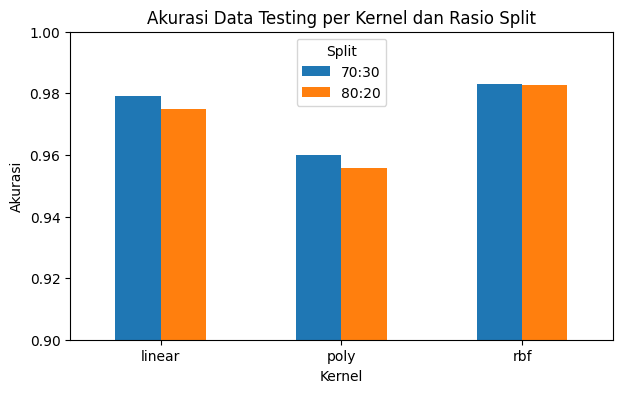

In [8]:
import matplotlib.pyplot as plt

tabel_akurasi.plot(kind='bar', figsize=(7, 4), rot=0)
plt.title('Akurasi Data Testing per Kernel dan Rasio Split')
plt.xlabel('Kernel')
plt.ylabel('Akurasi')
plt.ylim(0.9, 1.0)
plt.legend(title='Split')
plt.show()

> Dari tabel terlihat bahwa kernel RBF memberikan akurasi testing tertinggi pada kedua rasio split (0,9832 untuk 70:30 dan 0,9826 untuk 80:20), diikuti kernel linier (0,9790 dan 0,9748), sedangkan kernel polynomial paling rendah (0,9600 dan 0,9558). Kernel linier sudah cukup bagus, artinya data suara ini sebagian besar sudah dapat dipisahkan secara linier, tetapi RBF masih sedikit lebih unggul karena bisa membuat batas yang melengkung. Kernel polynomial dengan pengaturan default (derajat 3) justru kurang cocok untuk data ini. Untuk rasio split, 70:30 sedikit lebih tinggi daripada 80:20 pada semua kernel, tetapi selisihnya kurang dari 0,5 poin persentase sehingga bisa dibilang tidak berbeda jauh. Jadi, kombinasi terbaik adalah kernel RBF dengan split 70:30 (akurasi 98,32%).